Found 22348 images belonging to 22 classes.
Found 4800 images belonging to 22 classes.
Found 4720 images belonging to 22 classes.


/home/arut/miniconda3/envs/env/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 205s 290ms/step - accuracy: 0.3026 - loss: 2.4922 - val_accuracy: 0.7296 - val_loss: 0.9773
Epoch 2/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 199s 285ms/step - accuracy: 0.7104 - loss: 1.0544 - val_accuracy: 0.7771 - val_loss: 0.7372
Epoch 3/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 178s 255ms/step - accuracy: 0.7915 - loss: 0.7629 - val_accuracy: 0.8767 - val_loss: 0.4521
Epoch 4/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 179s 256ms/step - accuracy: 0.8419 - loss: 0.5687 - val_accuracy: 0.9008 - val_loss: 0.3527
Epoch 5/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 168s 240ms/step - accuracy: 0.8793 - loss: 0.4148 - val_accuracy: 0.9081 - val_loss: 0.3056
Epoch 6/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 171s 244ms/step - accuracy: 0.8937 - loss: 0.3602 - val_accuracy: 0.9169 - val_loss: 0.2800
Epoch 7/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 170s 244ms/step - accuracy: 0.8986 - loss: 0.3372 - val_accuracy: 0.9137 - val_loss: 0.2900
Epoch 8/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 169s 242ms/step - accuracy: 0.9143 -

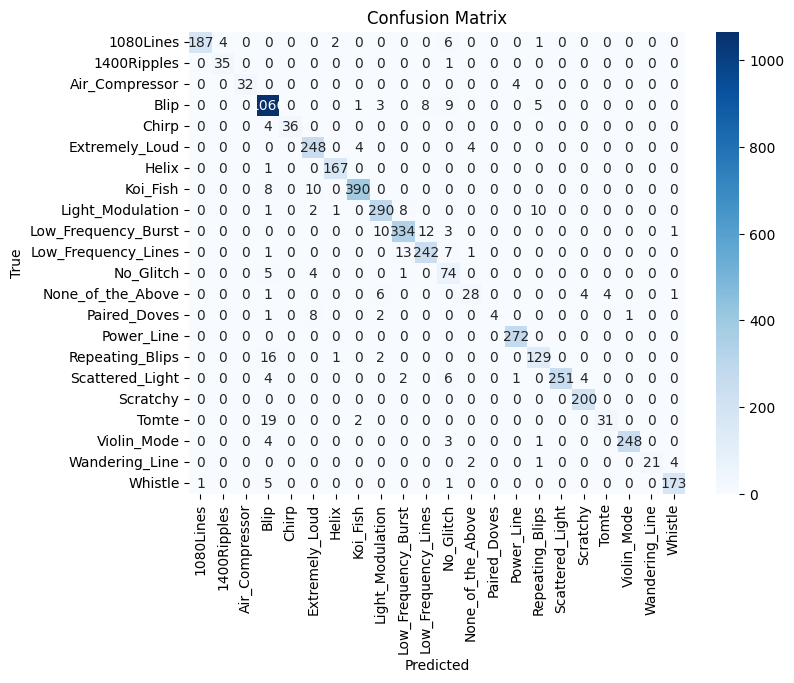

Classification Report:
                     precision    recall  f1-score   support

          1080Lines       0.99      0.94      0.96       200
        1400Ripples       0.90      0.97      0.93        36
     Air_Compressor       1.00      0.89      0.94        36
               Blip       0.94      0.98      0.96      1092
              Chirp       1.00      0.90      0.95        40
     Extremely_Loud       0.91      0.97      0.94       256
              Helix       0.98      0.99      0.99       168
           Koi_Fish       0.98      0.96      0.97       408
   Light_Modulation       0.93      0.93      0.93       312
Low_Frequency_Burst       0.93      0.93      0.93       360
Low_Frequency_Lines       0.92      0.92      0.92       264
          No_Glitch       0.67      0.88      0.76        84
  None_of_the_Above       0.80      0.64      0.71        44
       Paired_Doves       1.00      0.25      0.40        16
         Power_Line       0.98      1.00      0.99       272


In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------- Data Loading ----------------------
data_dir = "/home/arut/Gravityspy"  # CHANGE THIS

train_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train/train"), target_size=(64, 64), batch_size=32, class_mode="categorical", shuffle=False)
val_generator = val_datagen.flow_from_directory(
    os.path.join(data_dir, "validation/validation"), target_size=(64, 64), batch_size=32, class_mode="categorical", shuffle=False)
test_generator = test_datagen.flow_from_directory(
    os.path.join(data_dir, "test/test"), target_size=(64, 64), batch_size=32, class_mode="categorical", shuffle=False)

num_classes = len(train_generator.class_indices)

# ---------------------- CNN Model ----------------------
inputs = Input(shape=(64, 64, 3))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs, name="cnn_classifier")
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# ---------------------- Training ----------------------
history = model.fit(train_generator, epochs=20, validation_data=val_generator)

# ---------------------- Evaluation ----------------------
train_loss, train_acc = model.evaluate(train_generator)
val_loss, val_acc = model.evaluate(val_generator)
test_loss, test_acc = model.evaluate(test_generator)

print(f"Training Accuracy: {train_acc:.4f}, Training Loss: {train_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}, Validation Loss: {val_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# ---------------------- Confusion Matrix ----------------------
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
class_labels = list(train_generator.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ---------------------- Classification Report ----------------------
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# ---------------------- Save Model ----------------------
model.save("/home/arut/Downloads/Glitchveto/Trial_gravityspy/cnn_classifier_trial.h5")


Found 22348 images belonging to 22 classes.
Found 4800 images belonging to 22 classes.
Found 4720 images belonging to 22 classes.


/home/arut/miniconda3/envs/env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1742128295.204155    2915 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/arut/miniconda3/envs/env/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocess

Epoch 1/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 221s 313ms/step - accuracy: 0.5345 - loss: 2.3350 - val_accuracy: 0.8544 - val_loss: 0.5371
Epoch 2/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 208s 298ms/step - accuracy: 0.7572 - loss: 0.8422 - val_accuracy: 0.6202 - val_loss: 1.2803
Epoch 3/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 205s 293ms/step - accuracy: 0.7965 - loss: 0.7216 - val_accuracy: 0.8431 - val_loss: 0.5146
Epoch 4/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 201s 288ms/step - accuracy: 0.8416 - loss: 0.5077 - val_accuracy: 0.7479 - val_loss: 0.7620
Epoch 5/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 201s 287ms/step - accuracy: 0.8523 - loss: 0.4689 - val_accuracy: 0.6185 - val_loss: 1.7658
Epoch 6/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 201s 288ms/step - accuracy: 0.8646 - loss: 0.4163 - val_accuracy: 0.8925 - val_loss: 0.3824
Epoch 7/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 200s 286ms/step - accuracy: 0.8736 - loss: 0.3595 - val_accuracy: 0.9069 - val_loss: 0.3571
Epoch 8/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 201s 287ms/step - accuracy: 0.8790 -

148/148 ━━━━━━━━━━━━━━━━━━━━ 31s 207ms/step - accuracy: 0.8816 - loss: 2.4112
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 203ms/step - accuracy: 0.8542 - loss: 3.6219
✅ Test Accuracy: 89.70%
✅ Validation Accuracy: 87.98%
148/148 ━━━━━━━━━━━━━━━━━━━━ 29s 193ms/step


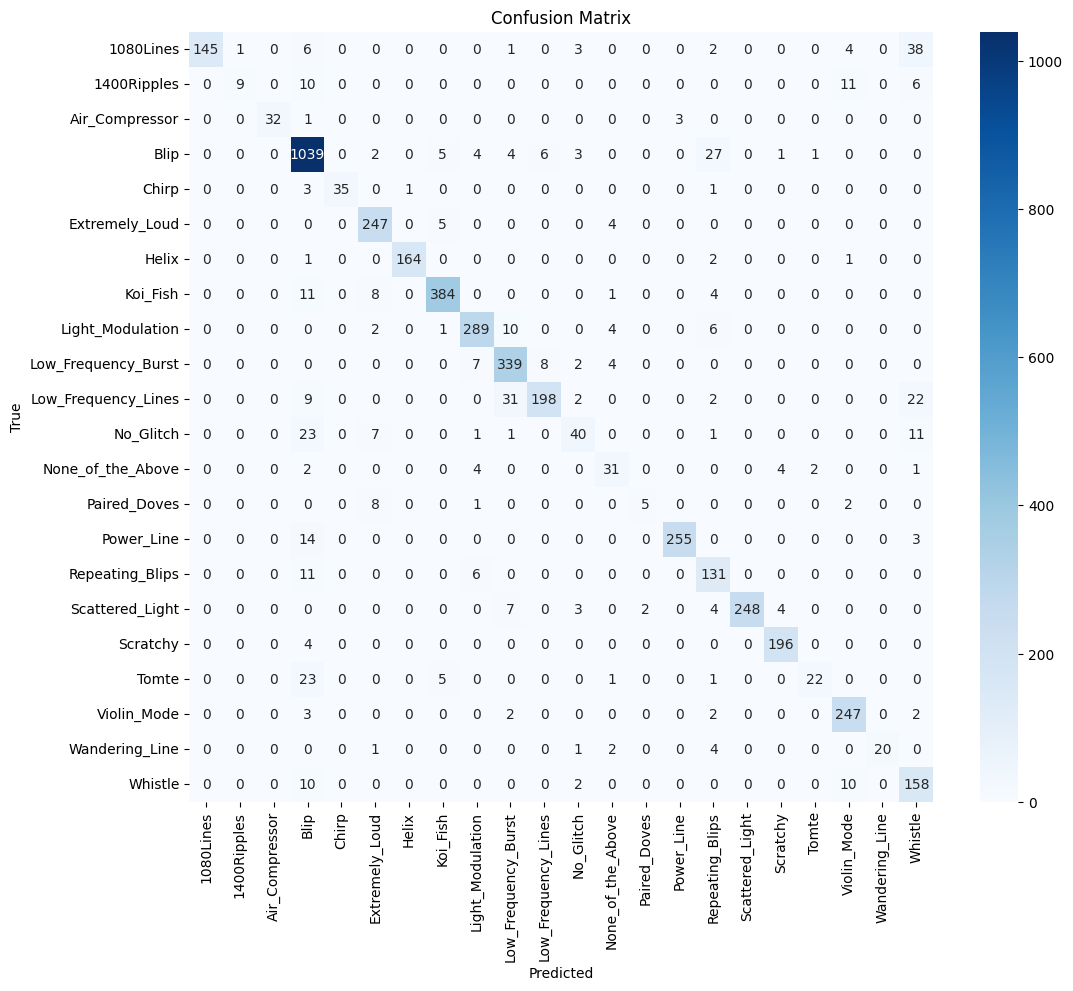

                     precision    recall  f1-score   support

          1080Lines       1.00      0.72      0.84       200
        1400Ripples       0.90      0.25      0.39        36
     Air_Compressor       1.00      0.89      0.94        36
               Blip       0.89      0.95      0.92      1092
              Chirp       1.00      0.88      0.93        40
     Extremely_Loud       0.90      0.96      0.93       256
              Helix       0.99      0.98      0.98       168
           Koi_Fish       0.96      0.94      0.95       408
   Light_Modulation       0.93      0.93      0.93       312
Low_Frequency_Burst       0.86      0.94      0.90       360
Low_Frequency_Lines       0.93      0.75      0.83       264
          No_Glitch       0.71      0.48      0.57        84
  None_of_the_Above       0.66      0.70      0.68        44
       Paired_Doves       0.71      0.31      0.43        16
         Power_Line       0.99      0.94      0.96       272
    Repeating_Blips    

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import os

# **🔹 Load Training, Validation, and Test Data**
img_size = (64, 64)
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    '/home/arut/Gravityspy/train/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    '/home/arut/Gravityspy/validation/validation',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    '/home/arut/Gravityspy/test/test',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# **🔹 Compute Class Weights for Imbalance**
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

# **🔹 Define CNN Model**
def build_model(num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=(64, 64, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    
    return model

num_classes = len(train_generator.class_indices)
model = build_model(num_classes)

# **🔹 Compile Model**
model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# **🔹 Train Model**
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights
)

# **🔹 Save the Model**
model.save("/home/arut/Downloads/Glitchveto/Trial_gravityspy/resnet_cnn_model.h5")

# **🔹 Evaluate on Test Set**
test_loss, test_acc = model.evaluate(test_generator)
val_loss, val_acc = model.evaluate(val_generator)

print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")
print(f"✅ Validation Accuracy: {val_acc * 100:.2f}%")

# **🔹 Plot Confusion Matrix**
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
class_labels = list(test_generator.class_indices.keys())

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# **🔹 Classification Report**
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


Found 22348 images belonging to 22 classes.
Found 4800 images belonging to 22 classes.
Found 4720 images belonging to 22 classes.


/home/arut/miniconda3/envs/env/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 195s 277ms/step - accuracy: 0.7316 - loss: 1.0115 - val_accuracy: 0.9029 - val_loss: 0.3208
Epoch 2/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 191s 274ms/step - accuracy: 0.9207 - loss: 0.2815 - val_accuracy: 0.9302 - val_loss: 0.2418
Epoch 3/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 192s 275ms/step - accuracy: 0.9441 - loss: 0.1816 - val_accuracy: 0.9367 - val_loss: 0.2340
Epoch 4/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 191s 274ms/step - accuracy: 0.9568 - loss: 0.1440 - val_accuracy: 0.9317 - val_loss: 0.2640
Epoch 5/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 193s 276ms/step - accuracy: 0.9637 - loss: 0.1202 - val_accuracy: 0.9394 - val_loss: 0.2405
Epoch 6/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 199s 284ms/step - accuracy: 0.9695 - loss: 0.1059 - val_accuracy: 0.9317 - val_loss: 0.2969
Epoch 7/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 198s 283ms/step - accuracy: 0.9754 - loss: 0.0833 - val_accuracy: 0.9410 - val_loss: 0.2568
Epoch 8/20
699/699 ━━━━━━━━━━━━━━━━━━━━ 195s 278ms/step - accuracy: 0.9788 -

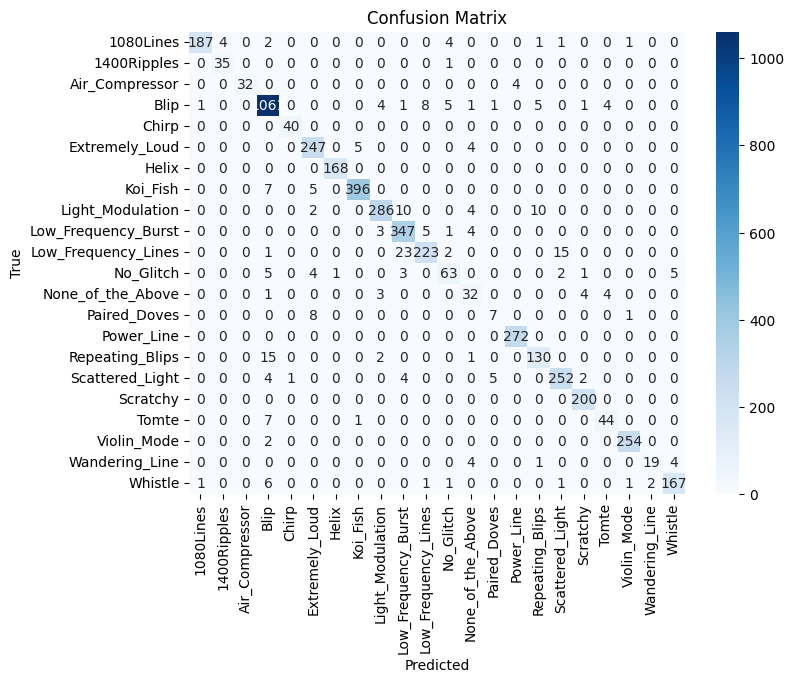

Classification Report:
                     precision    recall  f1-score   support

          1080Lines       0.99      0.94      0.96       200
        1400Ripples       0.90      0.97      0.93        36
     Air_Compressor       1.00      0.89      0.94        36
               Blip       0.95      0.97      0.96      1092
              Chirp       0.98      1.00      0.99        40
     Extremely_Loud       0.93      0.96      0.95       256
              Helix       0.99      1.00      1.00       168
           Koi_Fish       0.99      0.97      0.98       408
   Light_Modulation       0.96      0.92      0.94       312
Low_Frequency_Burst       0.89      0.96      0.93       360
Low_Frequency_Lines       0.94      0.84      0.89       264
          No_Glitch       0.82      0.75      0.78        84
  None_of_the_Above       0.64      0.73      0.68        44
       Paired_Doves       0.54      0.44      0.48        16
         Power_Line       0.99      1.00      0.99       272


In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------- Data Loading ----------------------
data_dir = "/home/arut/Gravityspy"  # CHANGE THIS

train_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train/train"), target_size=(64, 64), batch_size=32, class_mode="categorical", shuffle=True)
val_generator = val_datagen.flow_from_directory(
    os.path.join(data_dir, "validation/validation"), target_size=(64, 64), batch_size=32, class_mode="categorical", shuffle=False)
test_generator = test_datagen.flow_from_directory(
    os.path.join(data_dir, "test/test"), target_size=(64, 64), batch_size=32, class_mode="categorical", shuffle=False)

num_classes = len(train_generator.class_indices)

# ---------------------- CNN Model ----------------------
inputs = Input(shape=(64, 64, 3))

x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)  # ✅ Optional Batch Norm after first Conv layer
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)  # ✅ Reduced to 128 neurons
x = Dropout(0.3)(x)  # ✅ Reduced dropout from 0.5 to 0.3
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs, name="cnn_classifier")

# ---------------------- Compilation ----------------------
model.compile(optimizer=Adam(learning_rate=0.0005),  # ✅ Lower learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ---------------------- Training ----------------------
history = model.fit(train_generator, epochs=20, validation_data=val_generator)

# ---------------------- Evaluation ----------------------
train_loss, train_acc = model.evaluate(train_generator)
val_loss, val_acc = model.evaluate(val_generator)
test_loss, test_acc = model.evaluate(test_generator)

print(f"Training Accuracy: {train_acc:.4f}, Training Loss: {train_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}, Validation Loss: {val_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# ---------------------- Confusion Matrix ----------------------
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
class_labels = list(train_generator.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ---------------------- Classification Report ----------------------
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# ---------------------- Save Model ----------------------
model.save("cnn_classifier_3.h5")


Found 22348 images belonging to 22 classes.
Found 4800 images belonging to 22 classes.
Found 4720 images belonging to 22 classes.
Epoch 1/25
699/699 ━━━━━━━━━━━━━━━━━━━━ 302s 425ms/step - accuracy: 0.5682 - loss: 1.5285 - val_accuracy: 0.8021 - val_loss: 0.6670
Epoch 2/25
699/699 ━━━━━━━━━━━━━━━━━━━━ 273s 390ms/step - accuracy: 0.8728 - loss: 0.4577 - val_accuracy: 0.8512 - val_loss: 0.5142
Epoch 3/25
699/699 ━━━━━━━━━━━━━━━━━━━━ 272s 389ms/step - accuracy: 0.9070 - loss: 0.3381 - val_accuracy: 0.8846 - val_loss: 0.4098
Epoch 4/25
699/699 ━━━━━━━━━━━━━━━━━━━━ 263s 376ms/step - accuracy: 0.9173 - loss: 0.2893 - val_accuracy: 0.9185 - val_loss: 0.2824
Epoch 5/25
699/699 ━━━━━━━━━━━━━━━━━━━━ 264s 377ms/step - accuracy: 0.9346 - loss: 0.2341 - val_accuracy: 0.8594 - val_loss: 0.5185
Epoch 6/25
699/699 ━━━━━━━━━━━━━━━━━━━━ 270s 386ms/step - accuracy: 0.9447 - loss: 0.1984 - val_accuracy: 0.8981 - val_loss: 0.3512
Epoch 7/25
699/699 ━━━━━━━━━━━━━━━━━━━━ 278s 397ms/step - accuracy: 0.9508 - l

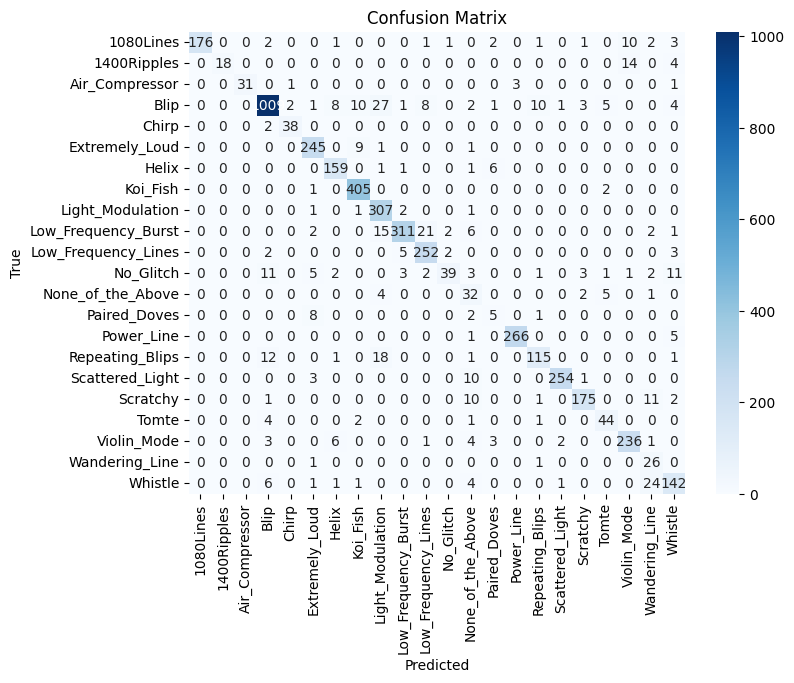

Classification Report:
                     precision    recall  f1-score   support

          1080Lines       1.00      0.88      0.94       200
        1400Ripples       1.00      0.50      0.67        36
     Air_Compressor       1.00      0.86      0.93        36
               Blip       0.96      0.92      0.94      1092
              Chirp       0.93      0.95      0.94        40
     Extremely_Loud       0.91      0.96      0.94       256
              Helix       0.89      0.95      0.92       168
           Koi_Fish       0.95      0.99      0.97       408
   Light_Modulation       0.82      0.98      0.90       312
Low_Frequency_Burst       0.96      0.86      0.91       360
Low_Frequency_Lines       0.88      0.95      0.92       264
          No_Glitch       0.89      0.46      0.61        84
  None_of_the_Above       0.41      0.73      0.52        44
       Paired_Doves       0.29      0.31      0.30        16
         Power_Line       0.99      0.98      0.98       272


In [5]:
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization,
                                     GlobalAveragePooling1D, Reshape, MultiHeadAttention, LayerNormalization, Add)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------- Data Loading ----------------------
data_dir = "/home/arut/Gravityspy"  # CHANGE THIS

train_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train/train"), target_size=(64, 64), batch_size=32, class_mode="categorical", shuffle=True)
val_generator = val_datagen.flow_from_directory(
    os.path.join(data_dir, "validation/validation"), target_size=(64, 64), batch_size=32, class_mode="categorical", shuffle=False)
test_generator = test_datagen.flow_from_directory(
    os.path.join(data_dir, "test/test"), target_size=(64, 64), batch_size=32, class_mode="categorical", shuffle=False)

num_classes = len(train_generator.class_indices)

# ---------------------- Transformer Block ----------------------
def transformer_block(inputs, num_heads=4, key_dim=64):
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(inputs, inputs)
    attn_output = Add()([inputs, attn_output])  # Residual Connection
    norm1 = LayerNormalization()(attn_output)
    return norm1

# ---------------------- CNN + Transformer Model ----------------------
inputs = Input(shape=(64, 64, 3))

# CNN Feature Extractor
x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)  # Final output shape: (8, 8, 256)

# Reshape for Transformer
x = Reshape((64, 256))(x)  # (Batch, 64 patches, 256 features) ✅ Fixed

# Transformer Block
x = transformer_block(x, num_heads=4, key_dim=64)

# Flatten for classification
x = GlobalAveragePooling1D()(x)  # Using 1D pooling since input is (Batch, Sequence, Features)

# Classification Head
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs, name="cnn_transformer_classifier")

# ---------------------- Compilation ----------------------
model.compile(optimizer=Adam(learning_rate=0.0003),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ---------------------- Training ----------------------
history = model.fit(train_generator, epochs=25, validation_data=val_generator)

# ---------------------- Evaluation ----------------------
train_loss, train_acc = model.evaluate(train_generator)
val_loss, val_acc = model.evaluate(val_generator)
test_loss, test_acc = model.evaluate(test_generator)

print(f"Training Accuracy: {train_acc:.4f}, Training Loss: {train_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}, Validation Loss: {val_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# ---------------------- Confusion Matrix ----------------------
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
class_labels = list(train_generator.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ---------------------- Classification Report ----------------------
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# ---------------------- Save Model ----------------------
model.save("/home/arut/Downloads/Glitchveto/Trial_gravityspy/cnn_transformer_classifier_4.h5")
